In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_bmw = pd.read_csv("bmw_data.csv")
print(df_bmw.head())


   car_id     model  year  engine_size  horsepower fuel_type transmission  \
0       1        X5  2016          4.0         272    diesel    automatic   
1       2  1 Series  2022          2.6         218    petrol    automatic   
2       3        X1  2012          2.2         240    petrol    automatic   
3       4        X5  2022          3.8         316    diesel          NaN   
4       5  7 Series  2023          3.1         294    petrol    automatic   

  drivetrain  mileage_km  fuel_consumption_l_per_100km  co2_emissions_g_km  \
0        AWD       74655                           8.9               196.0   
1        FWD       23469                           8.4               190.0   
2        FWD      123273                           7.8               174.0   
3        AWD       33064                           9.4               192.0   
4        RWD       23926                           NaN               204.0   

   price_usd  doors  seats  body_type  color  owner_count accident_h

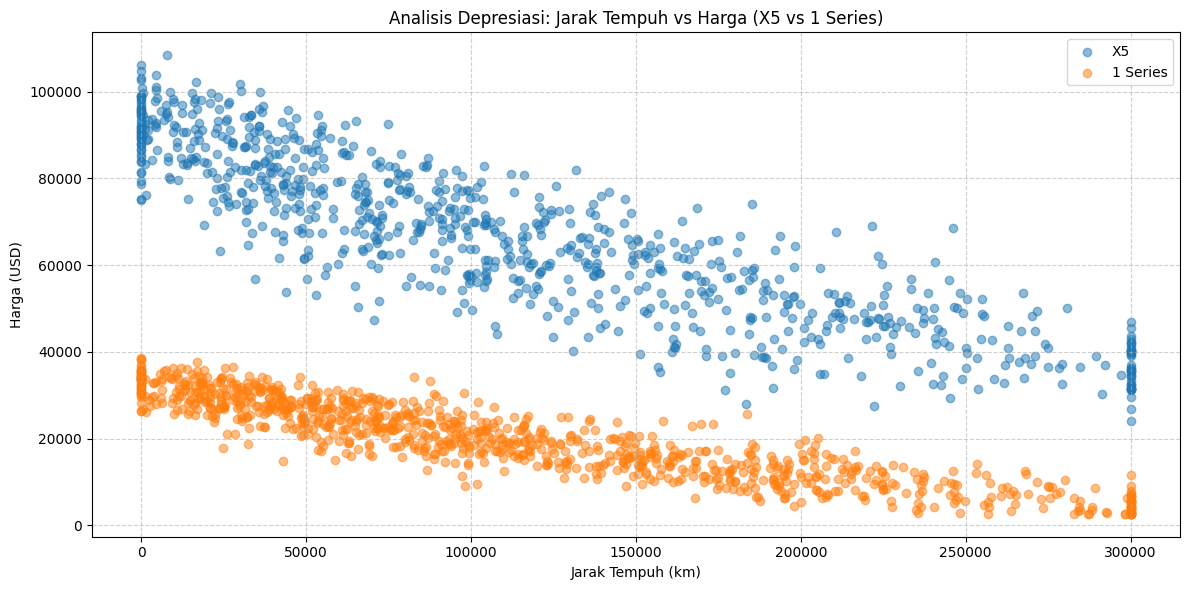

In [29]:
depreciation_df = df_bmw[['model', 'mileage_km', 'price_usd']].copy()

correlation = depreciation_df['mileage_km'].corr(depreciation_df['price_usd'])
# print(correlation)

models_to_compare = ['X5', '1 Series']
comparison_data = depreciation_df[depreciation_df['model'].isin(models_to_compare)]


plt.figure(figsize=(12, 6))
for model in models_to_compare:
    subset = comparison_data[comparison_data['model'] == model]
    plt.scatter(subset['mileage_km'], subset['price_usd'], alpha=0.5, label=model)

plt.title('Analisis Depresiasi: Jarak Tempuh vs Harga (X5 vs 1 Series)')
plt.xlabel('Jarak Tempuh (km)')
plt.ylabel('Harga (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

accident_history
no     54958.403261
yes    38416.818627
Name: price_usd, dtype: float64


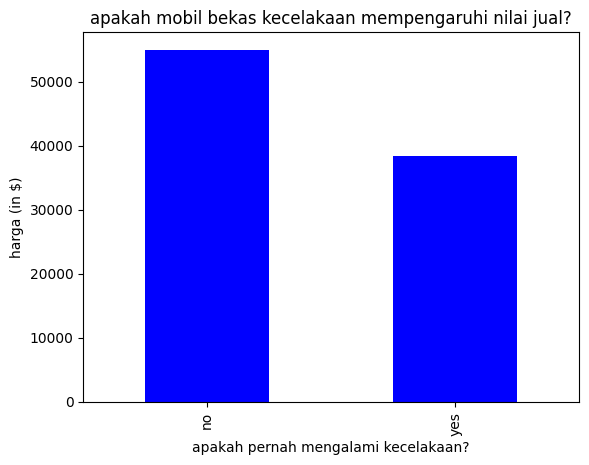

In [30]:
accident_history = (df_bmw.groupby("accident_history")["price_usd"].mean())
print(accident_history)

accident_history.plot(kind="bar", color = "blue")
plt.title("apakah mobil bekas kecelakaan mempengaruhi nilai jual?")
plt.xlabel("apakah pernah mengalami kecelakaan?")
plt.ylabel("harga (in $)")
plt.show()

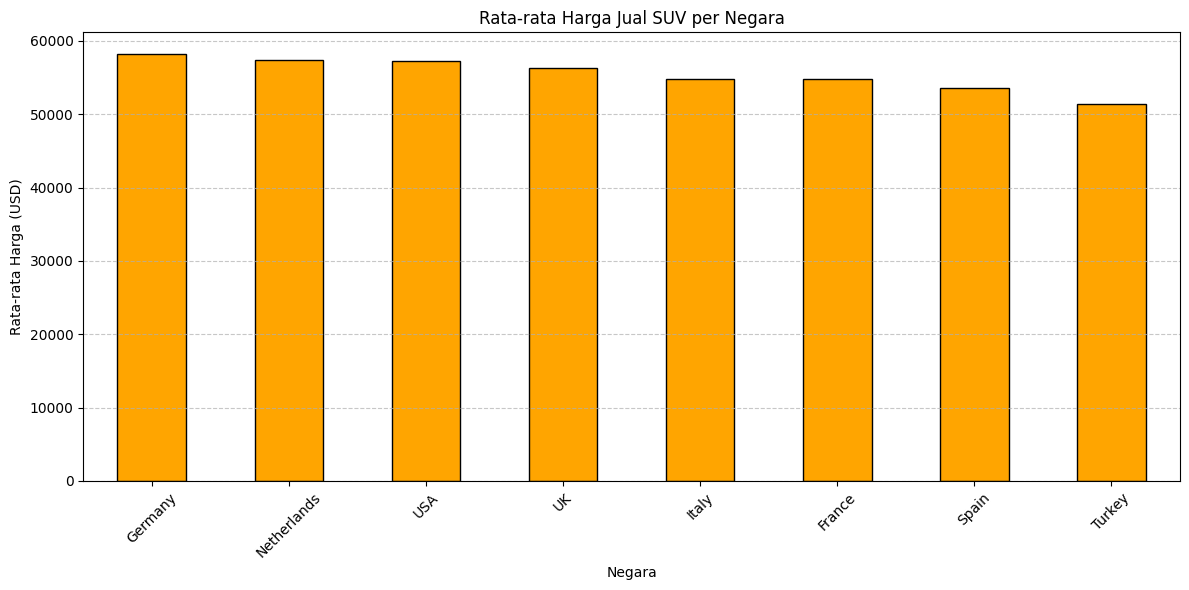


Rata-rata Harga SUV per Negara:
country_sold
Germany        58261.667436
Netherlands    57340.969758
USA            57211.865385
UK             56303.364253
Italy          54794.647423
France         54761.808421
Spain          53553.458167
Turkey         51422.625793
Name: price_usd, dtype: float64


In [31]:
suv_data = df_bmw[df_bmw['body_type'].str.lower() == 'suv']

# CATATAN
# Jika kolom body_type tidak tersedia, kita bisa filter berdasarkan model
# suv_models = ['X1', 'X3', 'X5', 'X6', 'X7']
# suv_data = df[df['model'].isin(suv_models)]

regional_suv_price = suv_data.groupby('country_sold')['price_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
regional_suv_price.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Rata-rata Harga Jual SUV per Negara')
plt.xlabel('Negara')
plt.ylabel('Rata-rata Harga (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nRata-rata Harga SUV per Negara:")
print(regional_suv_price)

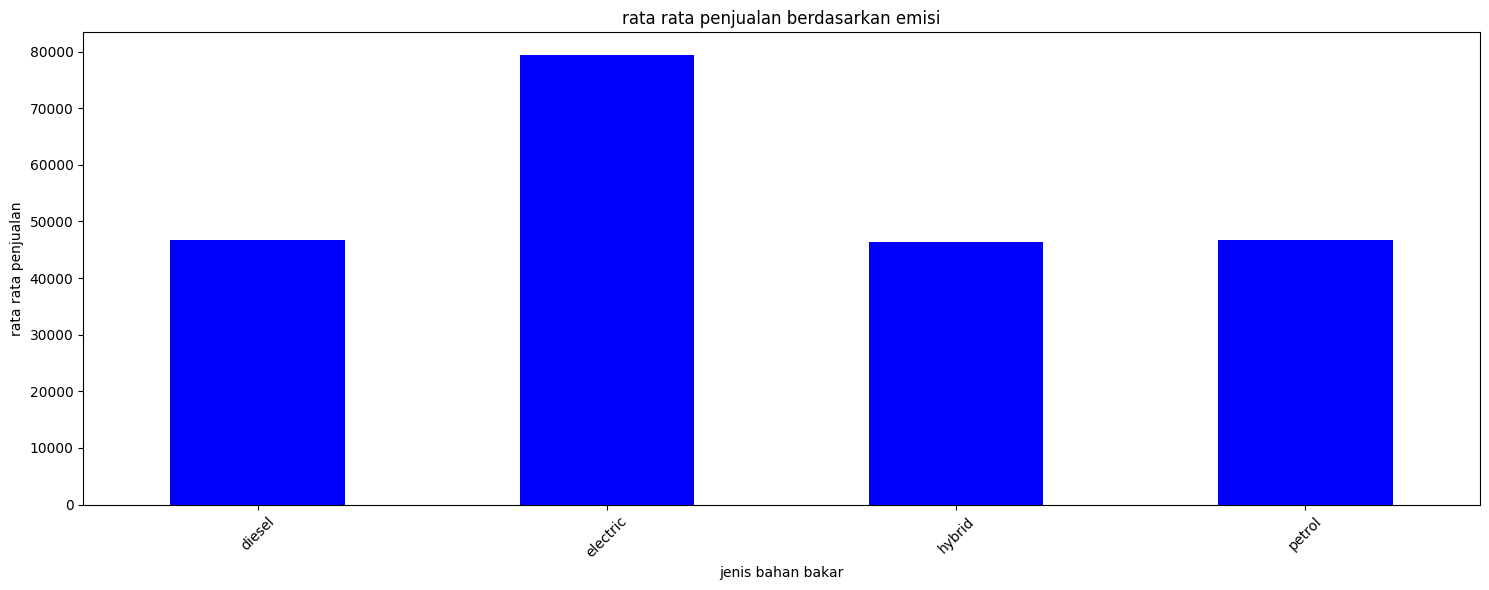

In [32]:
penjualan_berdasarkan_emisi = (df_bmw.groupby("fuel_type")["price_usd"].mean())
# print(penjualan_berdasarkan_emisi)

emisi_co2 = (df_bmw.groupby("fuel_type")["co2_emissions_g_km"].mean())
# print(emisi_co2)

plt.figure(figsize=(15, 6))
penjualan_berdasarkan_emisi.plot(kind = "bar", color = "blue")
plt.title('rata rata penjualan berdasarkan emisi')
plt.xlabel('jenis bahan bakar')
plt.ylabel('rata rata penjualan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_24217/634178287.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='price_usd', data=rekomendasi, palette='viridis')


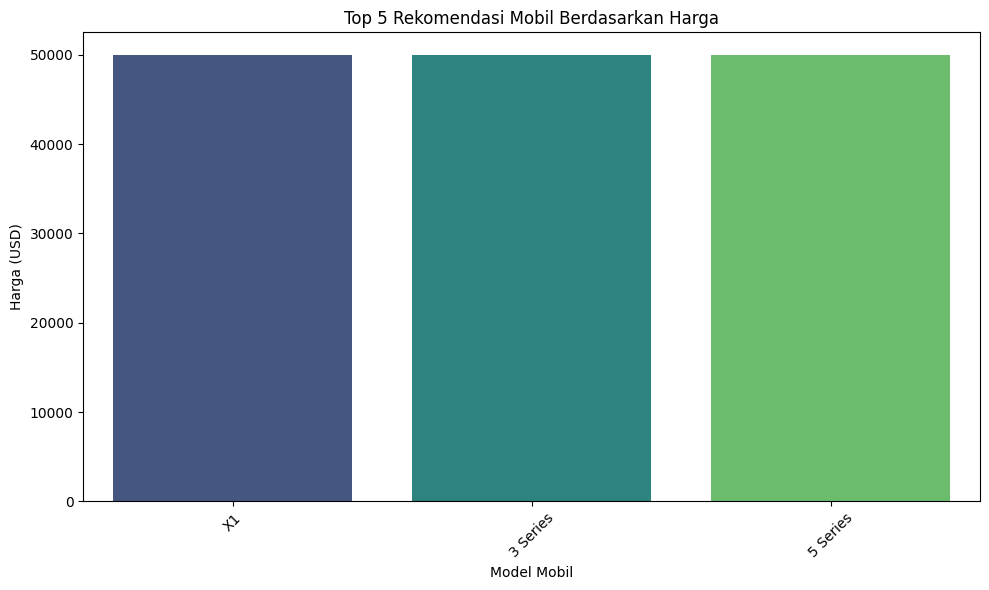

In [33]:
isi = df_bmw[["price_usd", "accident_history", "service_history", "model"]].copy()

rekomendasi = (isi[(isi["price_usd"] < 50000) & (isi["accident_history"] == "no") & (isi["service_history"] == "full")].sort_values("price_usd", ascending=False)).head(5)
# print(rekomendasi)

plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='price_usd', data=rekomendasi, palette='viridis')
plt.title('Top 5 Rekomendasi Mobil Berdasarkan Harga')
plt.xlabel('Model Mobil')
plt.ylabel('Harga (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
